
# PanelDataset Usage

In this example, we look at the basic functionality of PanelDataset. This is a dataclass that is used by modules in the package



* Example 1

    * In this example, we use the Meta sales dataset. First we import the csv file, then filter the data to only include pre-test data. Transform it to a wide data frame where the index (rows) are locations and the columnes are time. We then pass the dataframe to the PanelDataset. At this point, we can then perform operations on it using the other methods, classes and function in the Panel Exp package. 


In [14]:
import pandas as pd  
from panel_exp.panel_data import PanelDataset, TimePeriod

long_df = pd.read_csv('meta_geo.csv')

# trim data to only include pre-test data
long_df = long_df[long_df.time < 91]
wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')

wide_df.head()

time,1,2,3,4,5,6,7,8,9,10,...,81,82,83,84,85,86,87,88,89,90
location,,,,,,,,,,,,,,,,,,,,,
atlanta,3384.0,3904.0,5734.0,4311.0,3686.0,3374.0,3175.0,3594.0,4574.0,6866.0,...,5128.0,3564.0,3219.0,3348.0,4295.0,4960.0,7653.0,5182.0,4139.0,3504.0
austin,2124.0,2258.0,2994.0,2964.0,2134.0,2025.0,1954.0,2187.0,2523.0,3503.0,...,3046.0,2163.0,2250.0,2164.0,2495.0,2994.0,3424.0,3580.0,2462.0,2558.0
baltimore,3856.0,3821.0,5348.0,3915.0,2342.0,3585.0,3615.0,4015.0,4333.0,5951.0,...,4127.0,3583.0,3159.0,3569.0,4516.0,4808.0,6120.0,4615.0,3828.0,3779.0
baton rouge,2617.0,2609.0,3132.0,2554.0,2279.0,2157.0,2421.0,2841.0,3016.0,3816.0,...,2516.0,2238.0,2279.0,2472.0,3272.0,3567.0,4095.0,3032.0,2836.0,2690.0
boston,3122.0,3266.0,4393.0,5050.0,2727.0,2985.0,2616.0,3612.0,3774.0,4789.0,...,6007.0,2931.0,2882.0,3454.0,4055.0,4098.0,5587.0,6333.0,3403.0,3350.0


In [15]:
pds = PanelDataset(wide_df  )
print(pds)



        Panel Dataset Summary
        ---------------------
        Number of time points: 90
        Number of units: 40
        Number of treated units: 0
        Treated units: None
        Treated periods: None
        


* Example 2
    * In the first example, we only passed a dataframe to the PanelDataset. However, most of the time, we will want to pass several more pieces of information such as treated units and test periods. 

In [16]:
# aggregate treated units for TBR

control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'cincinnati', 'houston', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'cincinnati', 'houston', 'portland']].mean(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

# Define time variables
end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 14


In [17]:
pds = PanelDataset(wide_agg.T # DataFrame Units X Time. 
                   , treated_units = ['treated'] # List of treated units
                   , treated_periods=[TimePeriod(start=L-test_length)] # List of TimePeriod objects (one for each treated unit with start and end attributes. Or just a start attribute) 
                   )


In [18]:
print(pds.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 90
        Number of units: 36
        Number of treated units: 1
        Treated units: ['treated']
        Treated periods: [TimePeriod(start=76, end=None)]
        


As we can see, we passed a list of TimePeriods and a list of treated units. There needs to be a TimePeriod instance passed for each treated unit. You can pass and end date with the instance as well, but in this case the treated has no end period. 

* Plotting functions.

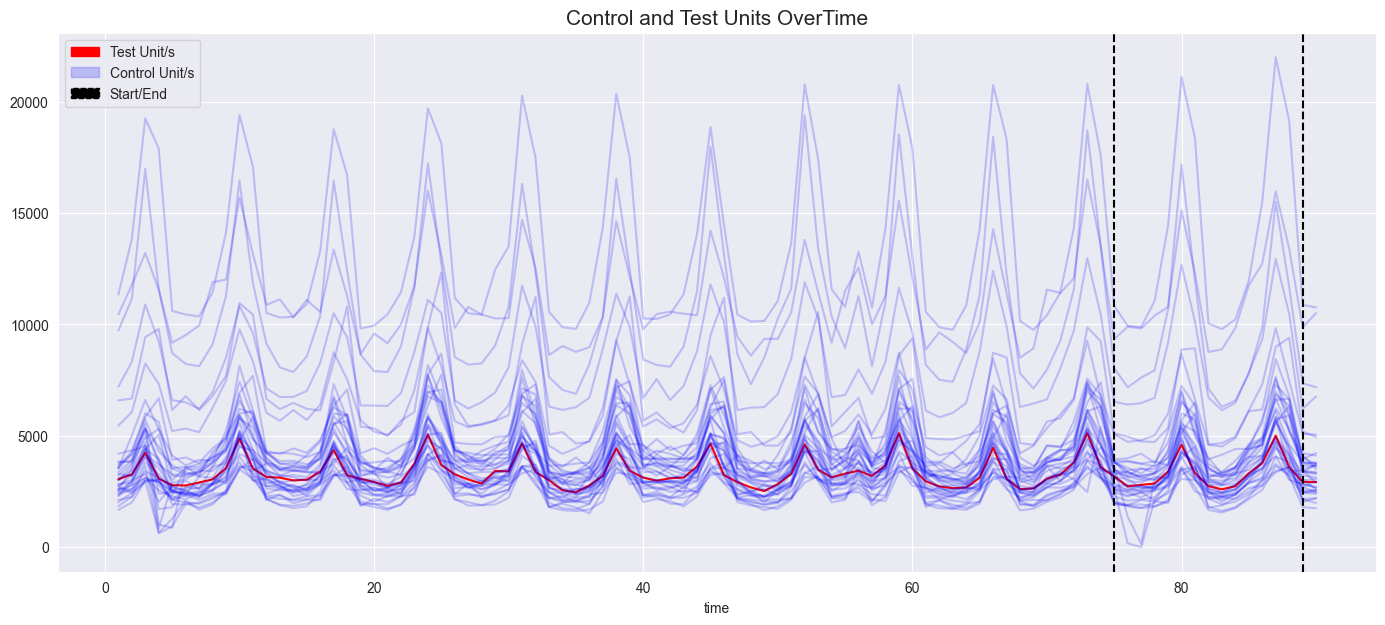

In [11]:
pds.plot_line()

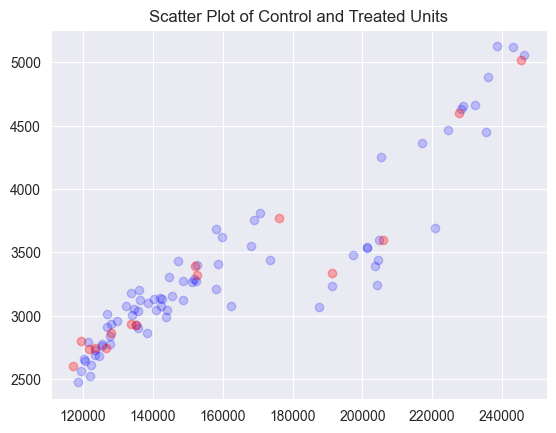

In [19]:
pds.plot_scatter()

At this point we can use the PanelDataset, pds, with other modules in the package. 

For complete documentation, please see the API reference. 
